In [1]:
import cartopy.crs as ccrs
import intake
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import easygems.healpix as egh
from utils import hp_mods, plot_all_fields
import warnings
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
import matplotlib.ticker as ticker
import os
import glob
import xarray as xr

ERROR 1: PROJ: proj_create_from_database: Open of /home/users/rwjones/.conda/envs/hk26_env/share/proj failed


In [2]:
warnings.filterwarnings("ignore", message=".*The return type of `Dataset.dims` will be changed.*", category=FutureWarning)

In [3]:
# Open catalog and print hk26 available models.
url = 'https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml'
cat = intake.open_catalog(url)['UK']
# Use online if not on JASMIN.
# cat = intake.open_catalog('https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml')['online']
print('\n'.join([k for k in cat if k.endswith('_hk26')]))

um_Africa_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26
um_Africa_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
um_CTC_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26
um_CTC_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
um_SAmer_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26
um_SAmer_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
um_SEA_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26
um_SEA_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
um_glm_n1280_CoMA9_hk26
um_glm_n1280_GAL9_v2_hk26
um_glm_n2560_CoMA9_hk26
um_glm_n2560_RAL3p3_tuned_hk26


In [4]:
# Load models.
# RALsim = 'um_glm_n2560_RAL3p3_tuned_hk26'
# RALsim_cat = cat[RALsim]

GALsim = 'um_glm_n1280_GAL9_v2_hk26'
GALsim_cat = cat[GALsim]

# COMA1sim = 'um_glm_n1280_CoMA9_hk26'
# COMA1sim_cat = cat[COMA1sim]

# COMA2sim = 'um_glm_n2560_CoMA9_hk26'
# COMA2sim_cat = cat[COMA2sim]

In [8]:
ds_imerg = cat['IR_IMERG'](zoom=9).to_dask().pipe(egh.attach_coords)
print(ds_imerg.time)

<xarray.DataArray 'time' (time: 52609)> Size: 421kB
array(['2019-01-01T00:00:00.000000000', '2019-01-01T00:30:00.000000000',
       '2019-01-01T01:00:00.000000000', ..., '2021-12-31T23:00:00.000000000',
       '2021-12-31T23:30:00.000000000', '2022-01-01T00:00:00.000000000'],
      shape=(52609,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 421kB 2019-01-01 ... 2022-01-01
    crs      int64 8B 0


In [6]:
# Crop both datasets to be only 1 year long

In [10]:
GAL1h = GALsim_cat(zoom=5, time='PT1H').to_dask().pipe(hp_mods)
print(GAL1h.dims)

FrozenMappingWarningOnValuesAccess({'time': 9745, 'cell': 12288, 'depth': 4})


In [37]:
# Southern Africa Mask
def saf_mask(ds):
    mask = (ds.lon > 0) & (ds.lon < 55) & (ds.lat > -45) & (ds.lat < 5)
    return mask

In [38]:
GAL_mask = GAL1h.where(saf_mask)
GAL_m = GAL_mask.pr.groupby("time.season").mean("time")

In [39]:
SCRATCH = "//work/scratch-nopw2/hjwood"
OUTFILE = f"{SCRATCH}/diff_GAL_IMERG.nc"

In [40]:
GAL_m.to_netcdf(OUTFILE)

In [26]:
IMERG_mask = ds_imerg.where(saf_mask)

In [28]:
IMERG_m = IMERG_mask.groupby("time.season").mean("time")

In [29]:
diff = GAL_m - IMERG_m

In [30]:
diff_plot = diff.compute()

KeyboardInterrupt: 

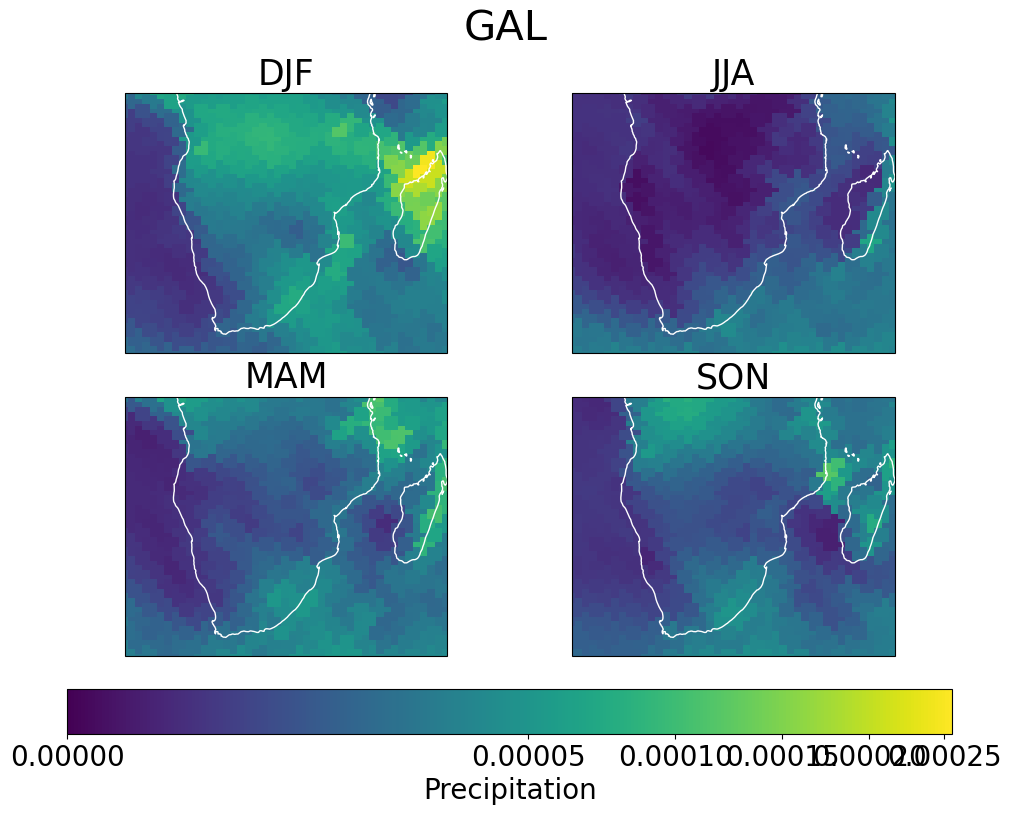

In [25]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import PowerNorm

# da = DataArray with dims ('season', 'cell')
# seasons: 'DJF', 'JJA', 'MAM', 'SON'

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 8),
    subplot_kw={"projection": ccrs.Robinson()},
    constrained_layout=True,
)

vmax = float(GAL_m.max())

for ax, s in zip(axes.flat, GAL_m.season.values):
    ax.set_global()
    plot = egh.healpix_show(
        GAL_m.sel(season=s),
        ax=ax,
        cmap="viridis",
        norm=PowerNorm(gamma=0.4, vmin=0, vmax=vmax),
    )
    ax.set_extent([5,50,-35,-5]) 
    ax.set_title(str(s), fontsize=25)
    ax.coastlines(color="white")

cbar = fig.colorbar(plot, ax=axes, orientation="horizontal")
cbar.set_label("Precipitation", fontsize=20)
cbar.ax.tick_params(labelsize=20)
fig.suptitle("GAL", fontsize=30)
plt.show()

In [5]:
# Open the 1hr datasets
# GAL1h = GALsim_cat(zoom=5, time='PT1H').to_dask().pipe(hp_mods)
# RAL1h = RALsim_cat(zoom=5, time='PT1H').to_dask().pipe(hp_mods)
# COMA1_1h = COMA1sim_cat(zoom=5, time='PT1H').to_dask().pipe(hp_mods)
# COMA2_1h = COMA2sim_cat(zoom=5, time='PT1H').to_dask().pipe(hp_mods)

In [5]:
time = pd.Timestamp('2021-05-18 13:00')

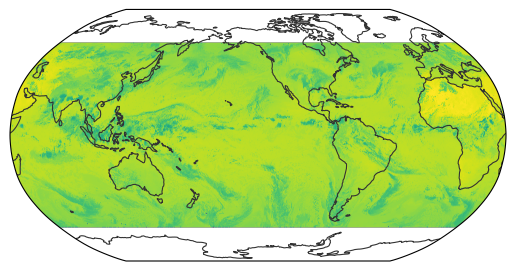

In [6]:
egh.healpix_show(ds_imerg.sel(time=time, method='nearest').Tb)